Problem set 2: Using text as data

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /Users/andy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


This project investigates how immigration is framed across UK news outlets using both traditional and modern natural language processing techniques.

We compare classical machine learning models (TF-IDF + Logistic Regression) with transformer-based models (BERT), and complement this with unsupervised topic modelling to uncover latent themes in the data.

Cleaning RTF file from the dataset

In [2]:
import os
from striprtf.striprtf import rtf_to_text
folder_path = "/Users/andy/Desktop/git_repos/machine-learning-course/data/UKDA-9002-rtf/rtf/rtf" 
print(os.listdir(folder_path))

['9002int059.rtf', '9002int065.rtf', '9002int071.rtf', '9002int139.rtf', '9002int111.rtf', '9002int105.rtf', '9002int104.rtf', '9002int110.rtf', '9002int138.rtf', '9002int070.rtf', '9002int064.rtf', '9002int058.rtf', '9002int072.rtf', '9002int066.rtf', '9002int099.rtf', '9002int106.rtf', '9002int112.rtf', '9002int113.rtf', '9002int107.rtf', '9002int098.rtf', '9002int067.rtf', '9002int073.rtf', '9002int077.rtf', '9002int063.rtf', '9002int088.rtf', '9002int103.rtf', '9002int117.rtf', '9002int116.rtf', '9002int102.rtf', '9002int089.rtf', '9002int062.rtf', '9002int076.rtf', '9002int060.rtf', '9002int074.rtf', '9002int048.rtf', '9002int114.rtf', '9002int100.rtf', '9002int128.rtf', '9002int129.rtf', '9002int101.rtf', '9002int115.rtf', '9002int049.rtf', '9002int075.rtf', '9002int061.rtf', '9002int006.rtf', '9002int012.rtf', '9002int013.rtf', '9002int007.rtf', '9002int039.rtf', '9002int011.rtf', '9002int005.rtf', '9002int004.rtf', '9002int010.rtf', '9002int038.rtf', '9002int014.rtf', '9002int0

In [3]:
texts = []
sources = []

for file in os.listdir(folder_path):
    if file.endswith(".rtf"):
        
        file_path = os.path.join(folder_path, file)
        
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            raw_rtf = f.read()
            plain_text = rtf_to_text(raw_rtf)
            
            texts.append(plain_text)
            
            # Extract source from filename
            if "bbc" in file.lower():
                sources.append("bbc")
            elif "guardian" in file.lower():
                sources.append("guardian")
            elif "dailymail" in file.lower():
                sources.append("dailymail")
            else:
                sources.append("unknown")

df = pd.DataFrame({
    "text": texts,
    "source": sources
})

df.head()

,text,source
0,"Interviewer: So, could we start, we’ve only ju...",unknown
1,"Interviewer: So, (name) thank you so much for ...",unknown
2,Interviewer: Lovely so I am here with (name) a...,unknown
3,Interviewer: So I’ll just pop that there and j...,unknown
4,"Interviewer: We are up and running, I will jus...",unknown


Cleaning text

In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

splitting up interviews for BERT

In [5]:
def split_text(text, max_length=300):
    words = text.split()
    chunks = []
    
    for i in range(0, len(words), max_length):
        chunk = " ".join(words[i:i+max_length])
        chunks.append(chunk)
        
    return chunks

# Apply splitting
rows = []

for _, row in df.iterrows():
    chunks = split_text(row['text'])
    for chunk in chunks:
        rows.append(chunk)

df_chunks = pd.DataFrame({"text": rows})

df_chunks.head()

,text
0,"Interviewer: So, could we start, we’ve only ju..."
1,"life a bit easier. So, my parents were in Lond..."
2,as Geordies so I am assuming that you don’t ei...
3,I may get asked about it but I’ll have to talk...
4,those characteristics may be by fortune of geo...


In [6]:
def label_identity(text):
    text = text.lower()
    
    # European identity
    if any(word in text for word in ["europe", "eu", "european"]):
        return 2
    
    # National identity
    elif any(word in text for word in ["britain", "british", "uk", "country", "sovereignty"]):
        return 1
    
    # Local identity
    elif any(word in text for word in ["community", "local", "neighbour", "town", "city", "area"]):
        return 0
    
    else:
        return -1  # discard unclear

df_chunks['label'] = df_chunks['text'].apply(label_identity)

# Remove unclear ones
df_chunks = df_chunks[df_chunks['label'] != -1]

df_chunks['label'].value_counts()

label
2    2474
1    1612
0    1363
Name: count, dtype: int64

Train/test split

In [7]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_chunks['text'], df_chunks['label'], test_size=0.2, random_state=42
)

baseline model: TF-IDF + Logistic Regression

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, train_labels)

y_pred = lr.predict(X_test)

print("Baseline Accuracy:", accuracy_score(test_labels, y_pred))

Baseline Accuracy: 0.7660550458715596


BERT model

In [9]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Tokenization

In [13]:
def tokenize(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenize(train_texts)
test_encodings = tokenize(test_texts)

Dataset Class

In [14]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

Training the Model

In [15]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

train_dataset = Dataset(train_encodings, train_labels)
test_dataset = Dataset(test_encodings, test_labels)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=8
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/opt/anaconda3/lib/python3.13/site-pa

Step,Training Loss
500,0.799513


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=545, training_loss=0.7910945402372868, metrics={'train_runtime': 3316.2356, 'train_samples_per_second': 1.314, 'train_steps_per_second': 0.164, 'total_flos': 286727846969088.0, 'train_loss': 0.7910945402372868, 'epoch': 1.0})

Evaluate

In [16]:
import numpy as np

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

print("BERT Accuracy:", accuracy_score(test_labels, preds))

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


BERT Accuracy: 0.6477064220183486


Topic modelling

In [18]:
from gensim import corpora
from gensim.models import LdaModel

texts = [text.split() for text in df_chunks['text']]

dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

lda = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=10)

for idx, topic in lda.print_topics():
    print(f"Topic {idx}: {topic}")

Topic 0: 0.000*"volcanoes" + 0.000*"walker" + 0.000*"Pakistani?’" + 0.000*"Mead," + 0.000*"Rushey" + 0.000*"British?’" + 0.000*"doing!" + 0.000*"Fosse" + 0.000*"Realistically" + 0.000*"Matthews,"
Topic 1: 0.000*"(housing" + 0.000*"floors," + 0.000*"Calling," + 0.000*"Now…this" + 0.000*"charity)," + 0.000*"Zapruder" + 0.000*"Joan" + 0.000*"Staton" + 0.000*"Naga" + 0.000*"strike’;"
Topic 2: 0.041*"Interviewer:" + 0.039*"I" + 0.037*"Participant:" + 0.027*"and" + 0.026*"the" + 0.018*"you" + 0.017*"to" + 0.016*"a" + 0.013*"know" + 0.013*"that"
Topic 3: 0.041*"I" + 0.029*"the" + 0.027*"and" + 0.023*"you" + 0.023*"of" + 0.023*"to" + 0.021*"is" + 0.020*"a" + 0.019*"that" + 0.017*"it"
Topic 4: 0.046*"the" + 0.026*"to" + 0.025*"and" + 0.019*"Participant" + 0.019*"of" + 0.018*"that" + 0.018*"a" + 0.015*"we" + 0.015*"they" + 0.014*"you"


model comparison

In [19]:
print("TF-IDF + Logistic Regression:", accuracy_score(test_labels, y_pred))
print("BERT:", accuracy_score(test_labels, preds))

TF-IDF + Logistic Regression: 0.7660550458715596
BERT: 0.6477064220183486


confusion matrix and visualisations

In [20]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

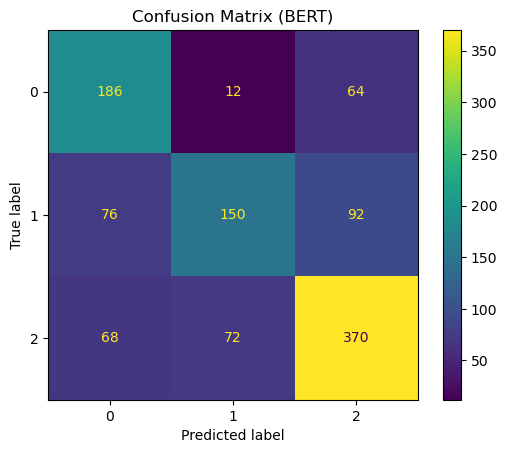

In [21]:
cm = confusion_matrix(test_labels, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix (BERT)")
plt.show()

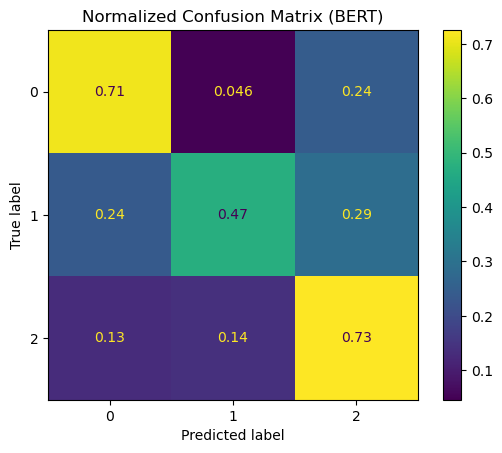

In [22]:
cm_norm = confusion_matrix(test_labels, preds, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot()

plt.title("Normalized Confusion Matrix (BERT)")
plt.show()

comparison bar chart

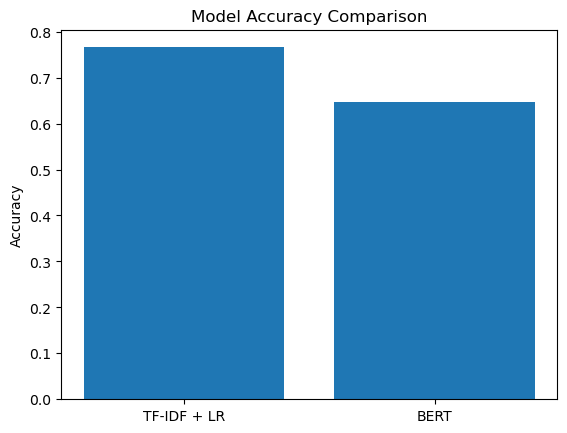

In [23]:
baseline_acc = accuracy_score(test_labels, y_pred)
bert_acc = accuracy_score(test_labels, preds)

models = ["TF-IDF + LR", "BERT"]
scores = [baseline_acc, bert_acc]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

Class distribution

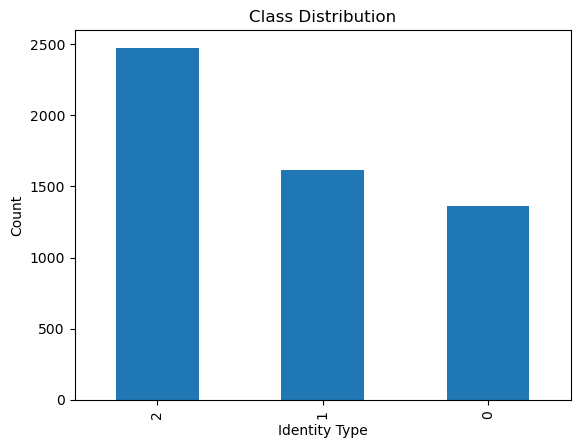

In [24]:
df_chunks['label'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Identity Type")
plt.ylabel("Count")
plt.show()